In [1]:
import sys
from pathlib import Path
import json

# Go up one level from notebooks/ → project_root/
PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

In [2]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_absolute_error,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

from src.preprocessing.meei_dataset import MEEIDataset
from src.preprocessing.transforms import get_basic_transform
from src.models.efficientnet_b0_model_v1 import MultiPoseEfficientNetB0

In [3]:
RUN_NAME = "efficientnet_b0_baseline_v1"

DATA_DIR = PROJECT_ROOT / "data"
MAN_DIR = DATA_DIR / "manifests"
RUNS_DIR = DATA_DIR / "runs"
EVAL_DIR = RUNS_DIR / RUN_NAME
EVAL_DIR.mkdir(parents=True, exist_ok=True)

PAR_PATH = MAN_DIR / "training_manifest_images_only.parquet"

CHECKPOINT_PATH = RUNS_DIR / f"{RUN_NAME}.pt"
HISTORY_PATH = RUNS_DIR / f"{RUN_NAME}_history.json"

print("Checkpoint:", CHECKPOINT_PATH)
print("History:", HISTORY_PATH)
print("Eval artifacts dir:", EVAL_DIR)

Checkpoint: /Users/willcrosswhite/Documents/All_Code/Palsy/palsy-detection-main/data/runs/efficientnet_b0_baseline_v1.pt
History: /Users/willcrosswhite/Documents/All_Code/Palsy/palsy-detection-main/data/runs/efficientnet_b0_baseline_v1_history.json
Eval artifacts dir: /Users/willcrosswhite/Documents/All_Code/Palsy/palsy-detection-main/data/runs/efficientnet_b0_baseline_v1


In [4]:
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)

Using device: mps


In [5]:
with open(HISTORY_PATH, "r") as f:
    history = json.load(f)

history.keys(), history["config"]

(dict_keys(['config', 'epochs']),
 {'batch_size': 4,
  'num_epochs': 15,
  'learning_rate': 0.0001,
  'dropout': 0.3,
  'freeze_backbone': True,
  'use_class_weights': True,
  'track_mae': True,
  'num_workers': 0,
  'run_name': 'efficientnet_b0_baseline_v1',
  'checkpoint_path': '/Users/willcrosswhite/Documents/All_Code/Palsy/palsy-detection-main/data/runs/efficientnet_b0_baseline_v1.pt',
  'history_path': '/Users/willcrosswhite/Documents/All_Code/Palsy/palsy-detection-main/data/runs/efficientnet_b0_baseline_v1_history.json'})

In [6]:
history_df = pd.DataFrame(history["epochs"])
history_df

,epoch,train_loss,train_acc,val_loss,val_acc,lr,train_mae,val_mae
0,1,1.776039,0.261905,1.780266,0.222222,0.00010,1.714286,2.555556
1,2,1.710252,0.357143,1.761785,0.222222,0.00010,1.428571,2.777778
2,3,1.675981,0.404762,1.774977,0.222222,0.00010,1.285714,3.000000
3,4,1.609124,0.595238,1.769256,0.222222,0.00010,0.714286,2.777778
4,5,1.543950,0.642857,1.769003,0.222222,0.00010,0.976190,2.555556
5,6,1.485286,0.690476,1.768677,0.222222,0.00005,0.619048,2.333333
6,7,1.442101,0.785714,1.755219,0.222222,0.00005,0.452381,2.111111
7,8,1.448171,0.714286,1.763218,0.222222,0.00005,0.690476,2.111111
8,9,1.434109,0.738095,1.750319,0.333333,0.00005,0.690476,1.555556
9,10,1.406200,0.761905,1.740710,0.444444,0.00005,0.500000,1.444444


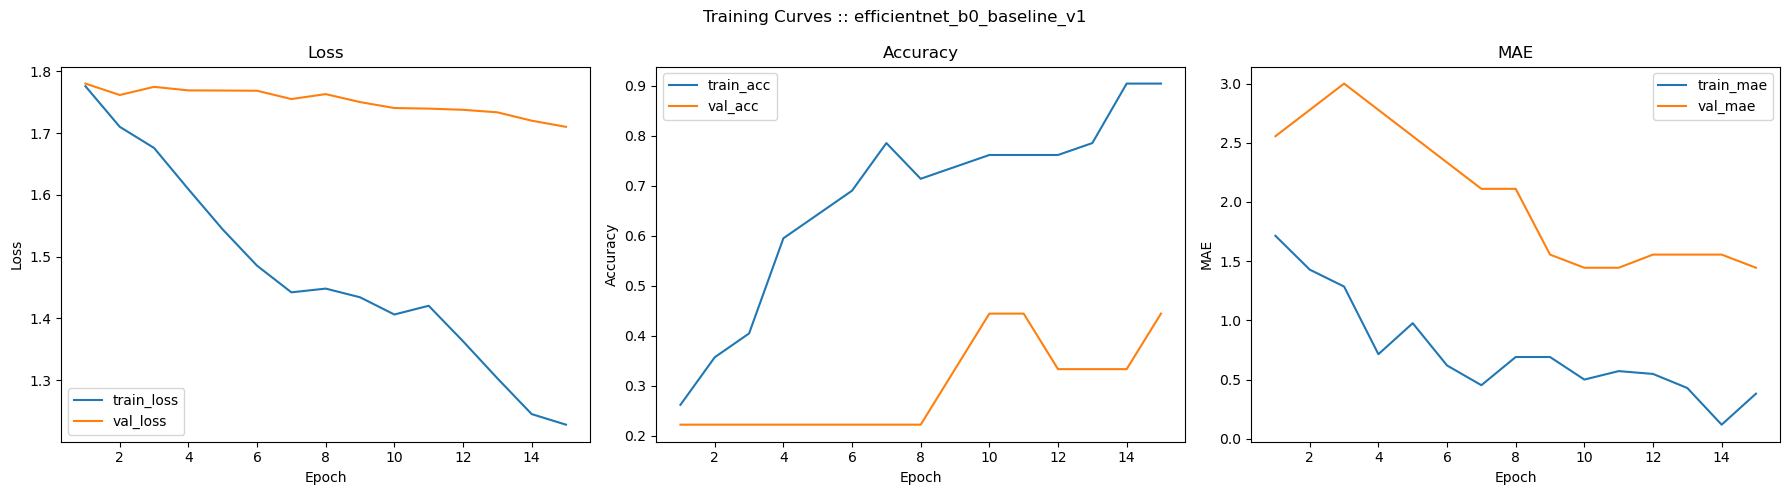

In [7]:
#Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Accuracy
axes[1].plot(history_df["epoch"], history_df["train_acc"], label="train_acc")
axes[1].plot(history_df["epoch"], history_df["val_acc"], label="val_acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

# MAE if present
if "train_mae" in history_df.columns and "val_mae" in history_df.columns:
    axes[2].plot(history_df["epoch"], history_df["train_mae"], label="train_mae")
    axes[2].plot(history_df["epoch"], history_df["val_mae"], label="val_mae")
    axes[2].set_title("MAE")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("MAE")
    axes[2].legend()
else:
    axes[2].axis("off")

plt.suptitle(f"Training Curves :: {RUN_NAME}")
plt.tight_layout()
plt.show()

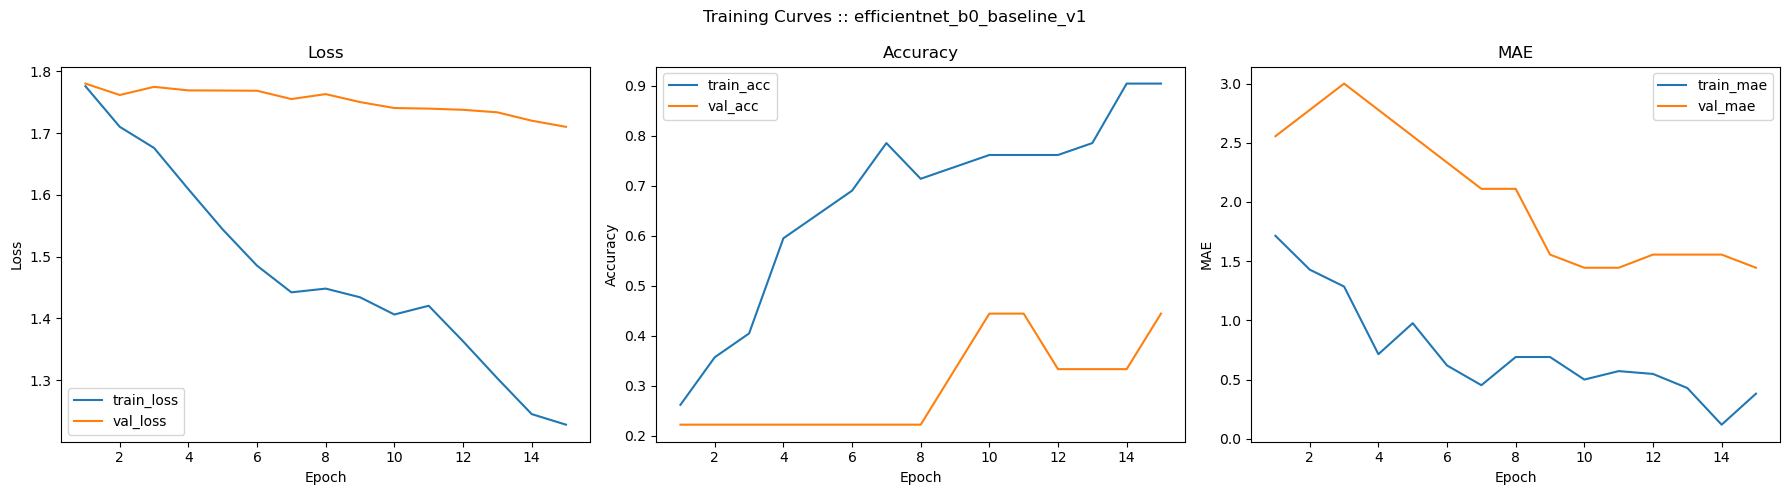

Saved: /Users/willcrosswhite/Documents/All_Code/Palsy/palsy-detection-main/data/runs/efficientnet_b0_baseline_v1/training_curves.png


In [8]:
#Save training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_acc"], label="train_acc")
axes[1].plot(history_df["epoch"], history_df["val_acc"], label="val_acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

if "train_mae" in history_df.columns and "val_mae" in history_df.columns:
    axes[2].plot(history_df["epoch"], history_df["train_mae"], label="train_mae")
    axes[2].plot(history_df["epoch"], history_df["val_mae"], label="val_mae")
    axes[2].set_title("MAE")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("MAE")
    axes[2].legend()
else:
    axes[2].axis("off")

plt.suptitle(f"Training Curves :: {RUN_NAME}")
plt.tight_layout()

curves_path = EVAL_DIR / "training_curves.png"
plt.savefig(curves_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", curves_path)

In [9]:
transform = get_basic_transform()

val_dataset = MEEIDataset(PAR_PATH, "val", transform)
val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0
)

print("Val size:", len(val_dataset))
print("Val batches:", len(val_loader))

Val size: 9
Val batches: 3


In [10]:
model = MultiPoseEfficientNetB0(
    num_classes=6,
    pretrained=False,
    dropout=history["config"]["dropout"]
).to(device)

state_dict = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(state_dict)
model.eval()

print("Model loaded.")

Model loaded.


In [11]:
all_preds = []
all_labels = []
all_patient_ids = []
all_confidences = []

with torch.no_grad():
    for batch in val_loader:
        images = batch["images"].to(device)
        labels = batch["label"].to(device).long()
        patient_ids = batch["patient_id"]

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        confs, preds = probs.max(dim=1)

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
        all_confidences.append(confs.cpu())
        all_patient_ids.extend(patient_ids)

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
all_confidences = torch.cat(all_confidences)

print("Pred HB:", all_preds + 1)
print("True HB:", all_labels + 1)

Pred HB: tensor([6, 6, 3, 6, 3, 6, 1, 5, 3])
True HB: tensor([6, 6, 3, 4, 2, 2, 1, 1, 5])


In [12]:
results_df = pd.DataFrame({
    "patient_id": all_patient_ids,
    "true_label": all_labels.numpy(),
    "pred_label": all_preds.numpy(),
    "true_hb": (all_labels + 1).numpy(),
    "pred_hb": (all_preds + 1).numpy(),
    "confidence": all_confidences.numpy(),
})

results_df["abs_error"] = (results_df["pred_hb"] - results_df["true_hb"]).abs()

results_df

,patient_id,true_label,pred_label,true_hb,pred_hb,confidence,abs_error
0,CompleteFlaccid1,5,5,6,6,0.201877,0
1,CompleteFlaccid5,5,5,6,6,0.246255,0
2,MildSynkinetic3,2,2,3,3,0.344776,0
3,ModerateFlaccid5,3,5,4,6,0.222519,2
4,NearNormalFlaccid3,1,2,2,3,0.238335,1
5,NearNormalSynkinetic2,1,5,2,6,0.382362,4
6,Normal4,0,0,1,1,0.269878,0
7,Normal6,0,4,1,5,0.244870,4
8,SevereFlaccid4,4,2,5,3,0.248174,2


In [13]:
predictions_path = EVAL_DIR / "predictions.csv"
results_df.to_csv(predictions_path, index=False)
print("Saved:", predictions_path)

Saved: /Users/willcrosswhite/Documents/All_Code/Palsy/palsy-detection-main/data/runs/efficientnet_b0_baseline_v1/predictions.csv


In [14]:
acc = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average="macro")
mae_zero_based = mean_absolute_error(all_labels, all_preds)
mae_hb = mean_absolute_error(all_labels + 1, all_preds + 1)

predicted_counts = torch.bincount(all_preds, minlength=6)
true_counts = torch.bincount(all_labels, minlength=6)

print(f"Accuracy: {acc:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"MAE (0-based): {mae_zero_based:.4f}")
print(f"MAE (HB): {mae_hb:.4f}")
print("Predicted counts:", predicted_counts)
print("True counts:     ", true_counts)

Accuracy: 0.4444
Macro F1: 0.3056
MAE (0-based): 1.4444
MAE (HB): 1.4444
Predicted counts: tensor([1, 0, 3, 0, 1, 4])
True counts:      tensor([2, 2, 1, 1, 1, 2])


In [15]:
report = classification_report(
    all_labels.numpy(),
    all_preds.numpy(),
    labels=[0, 1, 2, 3, 4, 5],
    target_names=["HB1", "HB2", "HB3", "HB4", "HB5", "HB6"],
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(report).T
report_df

,precision,recall,f1-score,support
HB1,1.000000,0.500000,0.666667,2.000000
HB2,0.000000,0.000000,0.000000,2.000000
HB3,0.333333,1.000000,0.500000,1.000000
HB4,0.000000,0.000000,0.000000,1.000000
HB5,0.000000,0.000000,0.000000,1.000000
HB6,0.500000,1.000000,0.666667,2.000000
accuracy,0.444444,0.444444,0.444444,0.444444
macro avg,0.305556,0.416667,0.305556,9.000000
weighted avg,0.370370,0.444444,0.351852,9.000000


In [16]:
metrics = {
    "run_name": RUN_NAME,
    "accuracy": float(acc),
    "macro_f1": float(macro_f1),
    "mae_zero_based": float(mae_zero_based),
    "mae_hb": float(mae_hb),
    "num_val_samples": int(len(all_labels)),
    "predicted_counts": predicted_counts.tolist(),
    "true_counts": true_counts.tolist(),
}

metrics_path = EVAL_DIR / "metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved:", metrics_path)
metrics

Saved: /Users/willcrosswhite/Documents/All_Code/Palsy/palsy-detection-main/data/runs/efficientnet_b0_baseline_v1/metrics.json


{'run_name': 'efficientnet_b0_baseline_v1',
 'accuracy': 0.4444444444444444,
 'macro_f1': 0.3055555555555555,
 'mae_zero_based': 1.4444444444444444,
 'mae_hb': 1.4444444444444444,
 'num_val_samples': 9,
 'predicted_counts': [1, 0, 3, 0, 1, 4],
 'true_counts': [2, 2, 1, 1, 1, 2]}

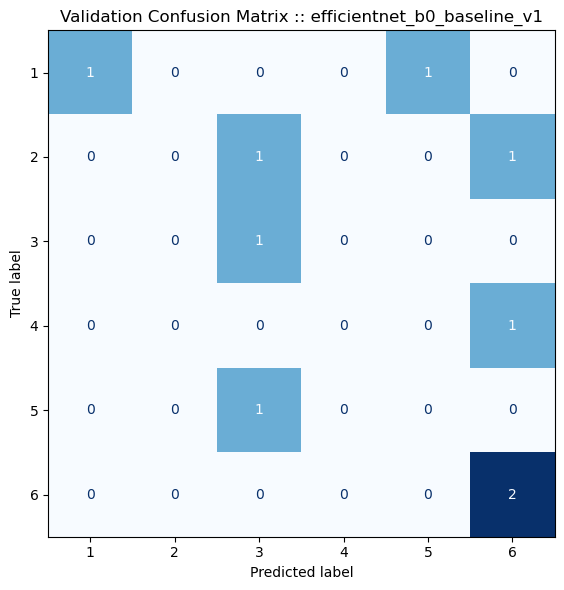

In [17]:
cm = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2, 3, 4, 5])

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[1, 2, 3, 4, 5, 6]
)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Validation Confusion Matrix :: {RUN_NAME}")
plt.tight_layout()
plt.show()

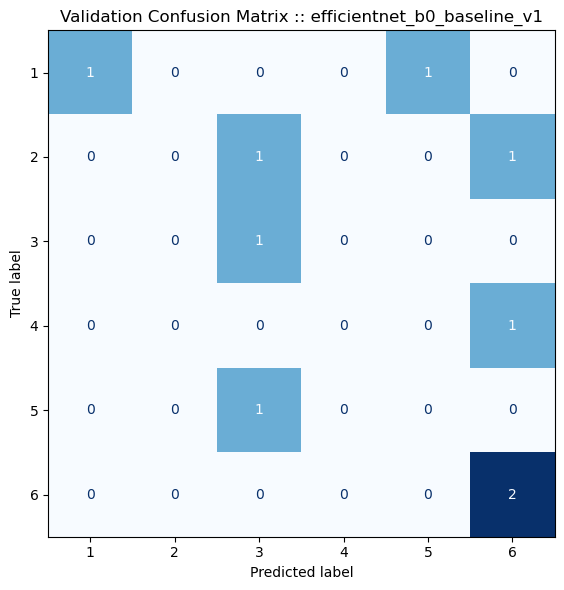

Saved: /Users/willcrosswhite/Documents/All_Code/Palsy/palsy-detection-main/data/runs/efficientnet_b0_baseline_v1/confusion_matrix.png


In [18]:
cm = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2, 3, 4, 5])

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[1, 2, 3, 4, 5, 6]
)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Validation Confusion Matrix :: {RUN_NAME}")
plt.tight_layout()

cm_path = EVAL_DIR / "confusion_matrix.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", cm_path)

In [19]:
exact = (results_df["abs_error"] == 0).sum()
off_by_one = (results_df["abs_error"] == 1).sum()
off_by_two_or_more = (results_df["abs_error"] >= 2).sum()

summary_df = pd.DataFrame({
    "bucket": ["exact", "off_by_one", "off_by_two_or_more"],
    "count": [exact, off_by_one, off_by_two_or_more]
})

summary_df

,bucket,count
0,exact,4
1,off_by_one,1
2,off_by_two_or_more,4


In [20]:
results_df.sort_values(["abs_error", "confidence"], ascending=[False, True]).head(10)

,patient_id,true_label,pred_label,true_hb,pred_hb,confidence,abs_error
7,Normal6,0,4,1,5,0.244870,4
5,NearNormalSynkinetic2,1,5,2,6,0.382362,4
3,ModerateFlaccid5,3,5,4,6,0.222519,2
8,SevereFlaccid4,4,2,5,3,0.248174,2
4,NearNormalFlaccid3,1,2,2,3,0.238335,1
0,CompleteFlaccid1,5,5,6,6,0.201877,0
1,CompleteFlaccid5,5,5,6,6,0.246255,0
6,Normal4,0,0,1,1,0.269878,0
2,MildSynkinetic3,2,2,3,3,0.344776,0


In [21]:
note = f"""# Evaluation Summary :: {RUN_NAME}

## Metrics
- Accuracy: {acc:.4f}
- Macro F1: {macro_f1:.4f}
- MAE (HB): {mae_hb:.4f}
- Validation samples: {len(all_labels)}

## Prediction distribution
- Predicted counts: {predicted_counts.tolist()}
- True counts: {true_counts.tolist()}

## Initial interpretation
- Model does {'not ' if len(torch.nonzero(predicted_counts).flatten()) <= 1 else ''}appear collapsed.
- Adjacent-grade confusion should be expected on this ordinal task.
- This run should be compared against future experiments like frozen-backbone, weighted-loss, and MAE-tracked variants.

## Next experiment
- Freeze backbone
- Add class weights
- Keep MAE tracking
"""

note_path = EVAL_DIR / "research_note.md"
with open(note_path, "w") as f:
    f.write(note)

print("Saved:", note_path)
print(note)

Saved: /Users/willcrosswhite/Documents/All_Code/Palsy/palsy-detection-main/data/runs/efficientnet_b0_baseline_v1/research_note.md
# Evaluation Summary :: efficientnet_b0_baseline_v1

## Metrics
- Accuracy: 0.4444
- Macro F1: 0.3056
- MAE (HB): 1.4444
- Validation samples: 9

## Prediction distribution
- Predicted counts: [1, 0, 3, 0, 1, 4]
- True counts: [2, 2, 1, 1, 1, 2]

## Initial interpretation
- Model does appear collapsed.
- Adjacent-grade confusion should be expected on this ordinal task.
- This run should be compared against future experiments like frozen-backbone, weighted-loss, and MAE-tracked variants.

## Next experiment
- Freeze backbone
- Add class weights
- Keep MAE tracking

